Universidad del Valle de Guatemala
Departamento de Computación
Proyecto 1 - Visión por Computadora - Sección 10

Integrantes:
- Diego Alexander Hernández Silvestre - 21270
- Linda Inés Jiménez Vides - 21169
- José Andrés Auyón Cóbar - 201579 
 

# Problema 1 - Algoritmos de binarización

Libs 📚

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

Funciones de utilidad 🗂️

In [4]:
# Function to load a PGM image
def loadPGM(ruta):
    with open(ruta, 'r') as f:
        header = f.readline().strip()  # Leer "P2"
        if header != "P2":
            raise ValueError(f"Formato no soportado: {header}. Se esperaba P2.")

        # Leer comentarios
        dimensiones = f.readline().strip()
        while dimensiones.startswith("#"):
            dimensiones = f.readline().strip()

        width, height = map(int, dimensiones.split())  # Convertir dimensiones
        max_val = int(f.readline().strip())  # Leer máximo valor (255)

        # Leer los píxeles en formato texto y convertirlos a matriz NumPy
        img_data = np.array([int(valor) for valor in f.read().split()], dtype=np.uint8)
        img_data = img_data.reshape((height, width))  # Convertir a imagen

    return img_data


# Function to show the original image and the ground truth
def showImages(image, groundTruth, fileName):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(image, cmap='gray')
    plt.title(f'Imagen Original: {fileName}')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(groundTruth, cmap='gray')
    plt.title(f'Ground Truth: {fileName}')
    plt.axis('off')
    plt.show()


Visualizar imágenes proporcionadas 🔍

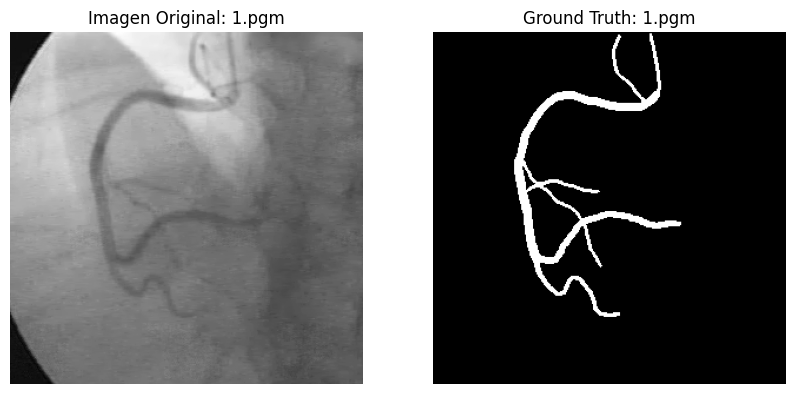

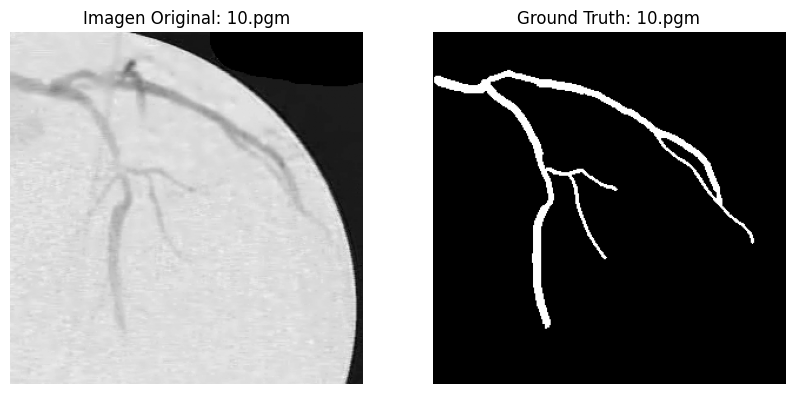

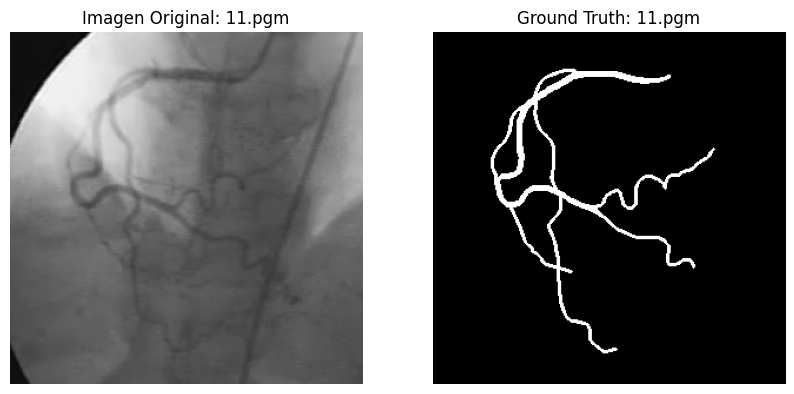

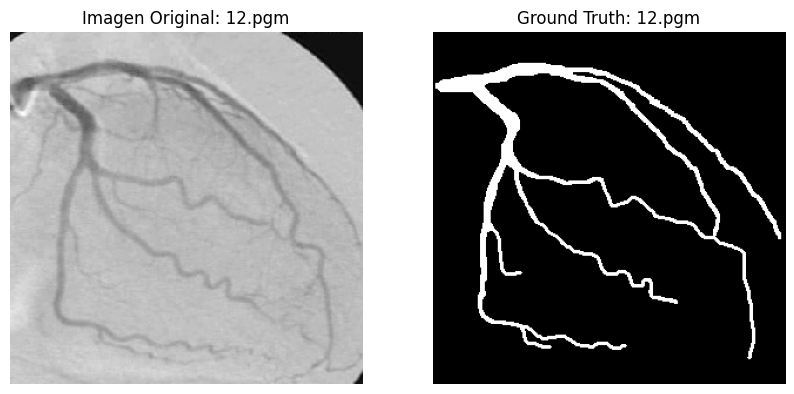

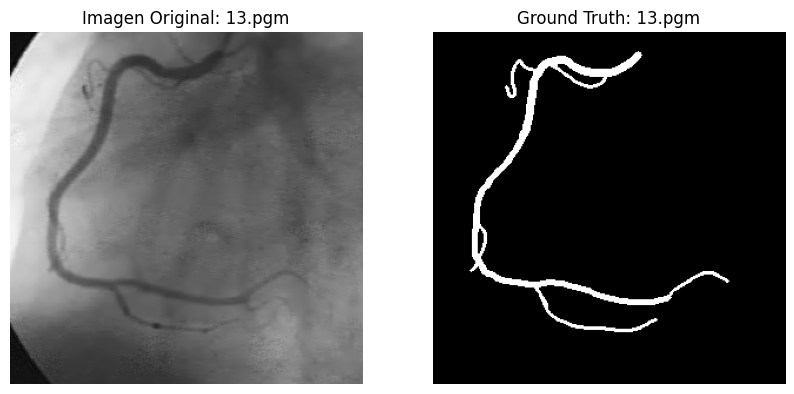

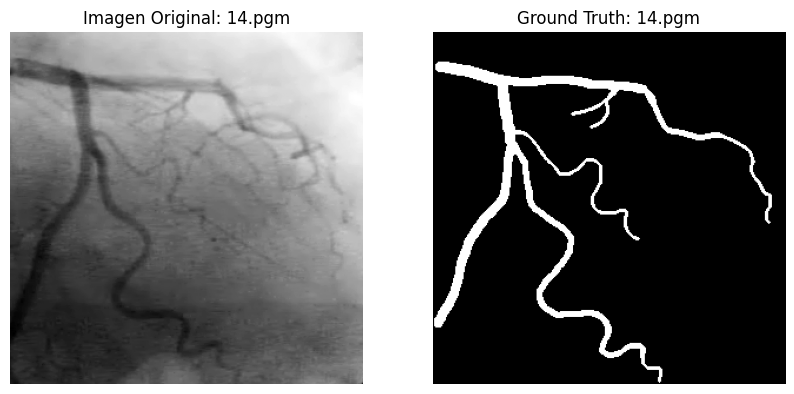

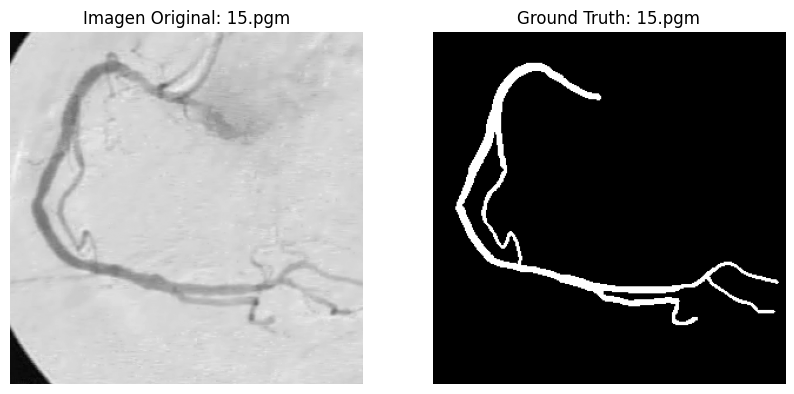

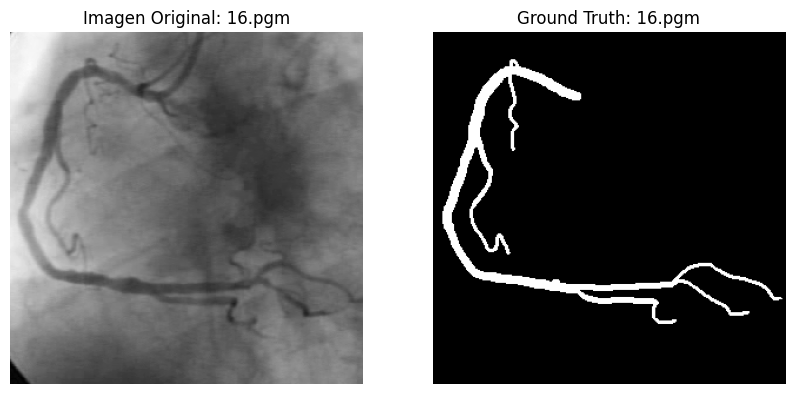

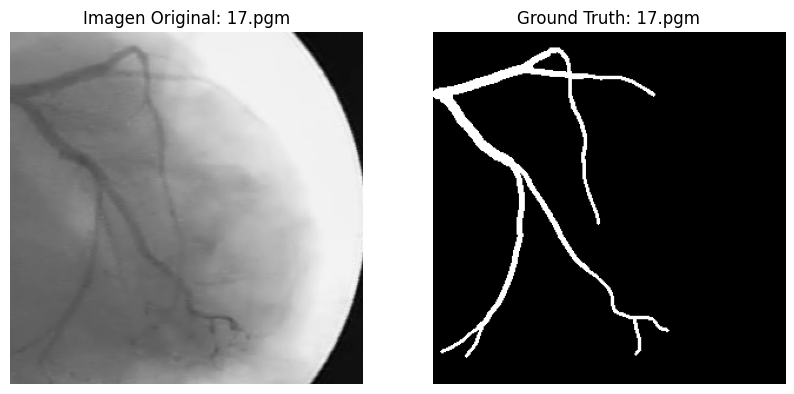

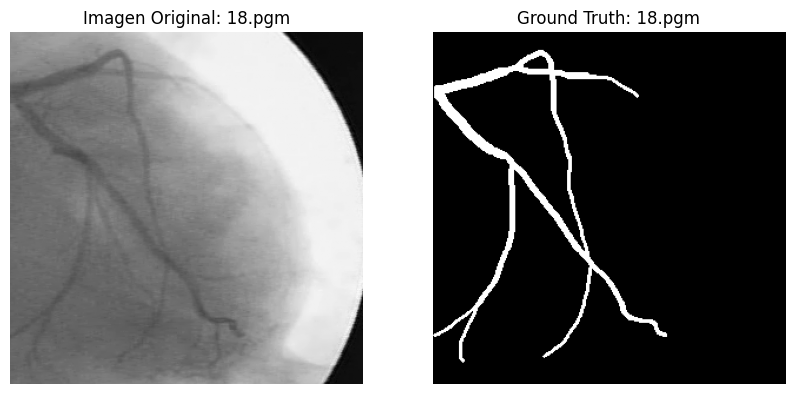

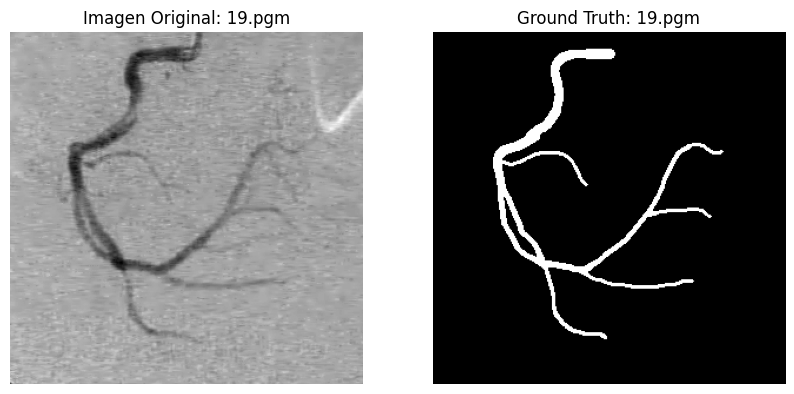

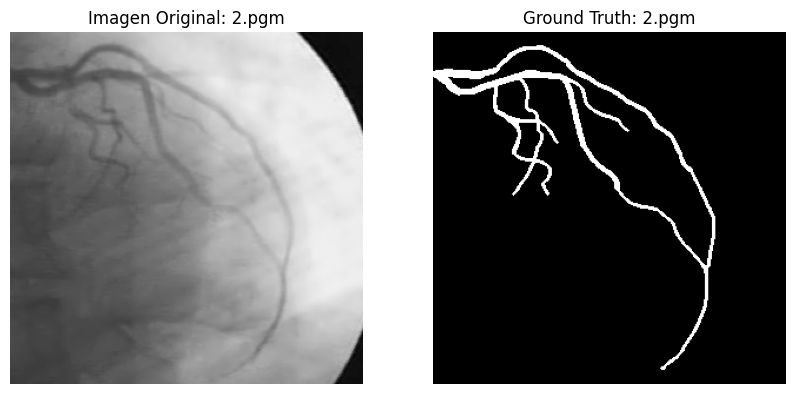

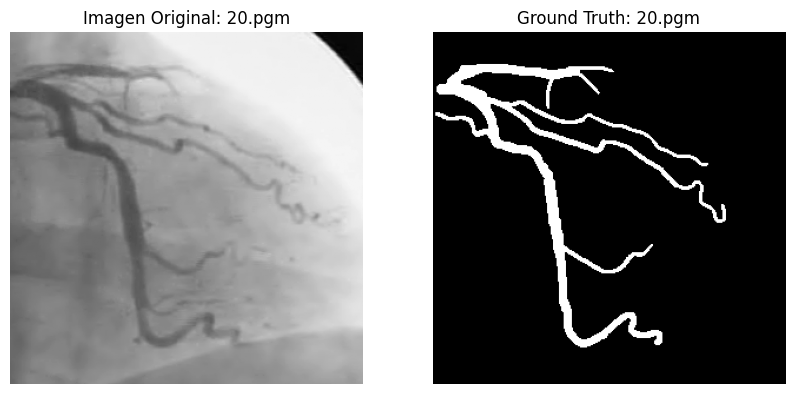

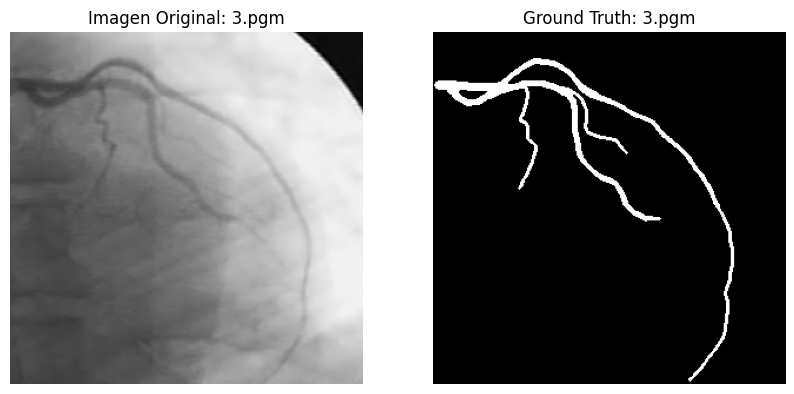

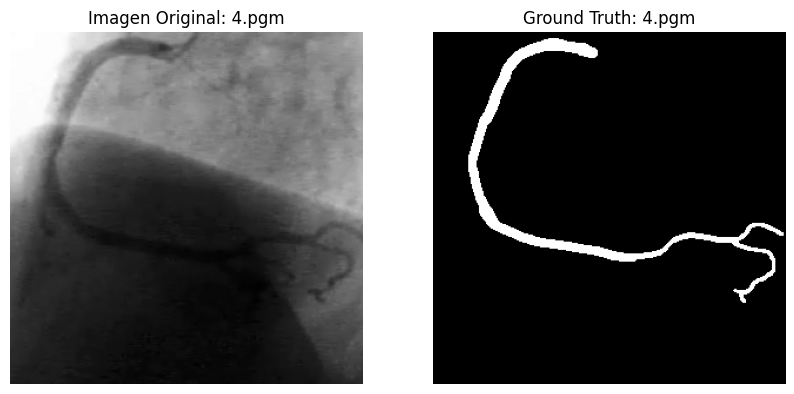

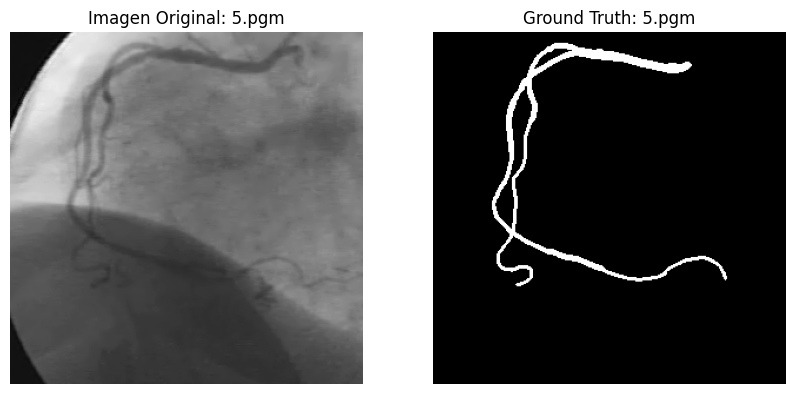

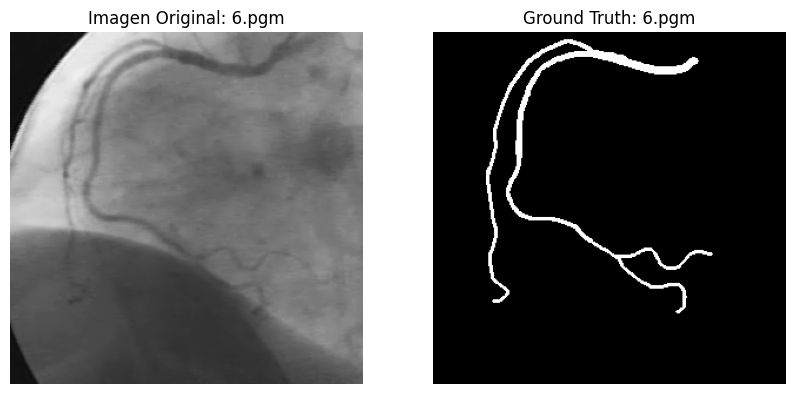

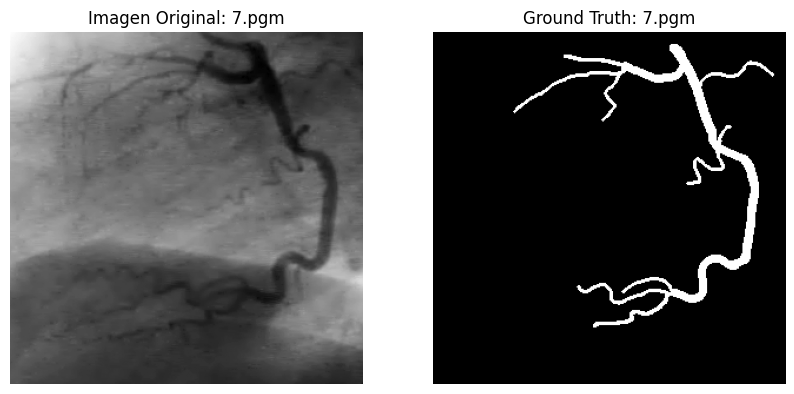

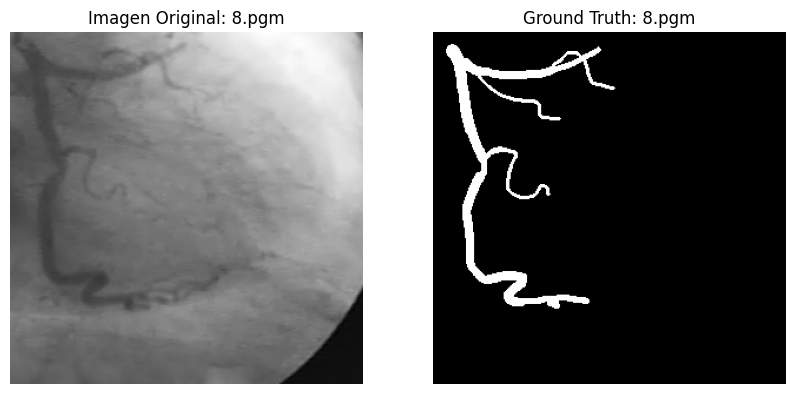

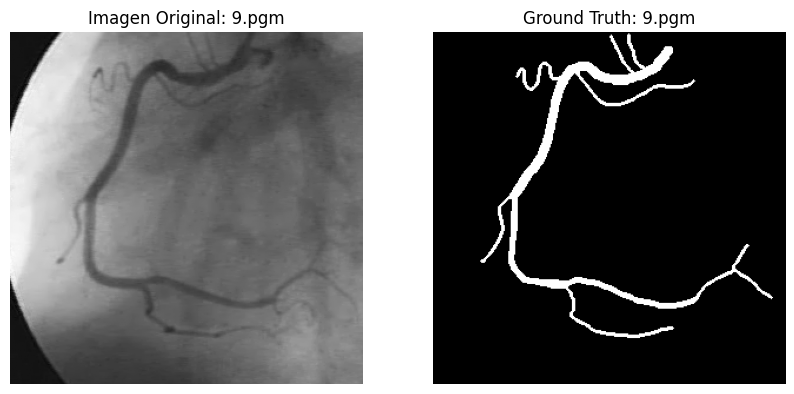

In [5]:
directorio = "database/database/"
archivos = sorted(os.listdir(directorio))
originalNames = [archivo for archivo in archivos if archivo.endswith(".pgm") and "_gt" not in archivo]
for name in originalNames:
    originalPath = os.path.join(directorio, name)
    gtPath = os.path.join(directorio, name.replace(".pgm", "_gt.pgm"))
    if os.path.exists(originalPath) and os.path.exists(gtPath):
        imagen = loadPGM(originalPath)
        groundTruth = loadPGM(gtPath)
        showImages(imagen, groundTruth, name)


Resultados de Evaluación:
╒══════════╤════════════╤══════════╤═══════════════╤═════════════╤════════════╕
│ Imagen   │   Accuracy │   Recall │   Specificity │   Precision │   F1 Score │
╞══════════╪════════════╪══════════╪═══════════════╪═════════════╪════════════╡
│ 1.pgm    │   0.977256 │ 0.642423 │      0.991939 │    0.777529 │   0.703548 │
├──────────┼────────────┼──────────┼───────────────┼─────────────┼────────────┤
│ 13.pgm   │   0.974644 │ 0.735475 │      0.984552 │    0.663558 │   0.697668 │
├──────────┼────────────┼──────────┼───────────────┼─────────────┼────────────┤
│ 5.pgm    │   0.974578 │ 0.462366 │      0.993798 │    0.736662 │   0.568139 │
├──────────┼────────────┼──────────┼───────────────┼─────────────┼────────────┤
│ 15.pgm   │   0.972656 │ 0.649536 │      0.989332 │    0.758593 │   0.699841 │
├──────────┼────────────┼──────────┼───────────────┼─────────────┼────────────┤
│ 19.pgm   │   0.972078 │ 0.47159  │      0.9964   │    0.864236 │   0.610206 │
├──────────┼─

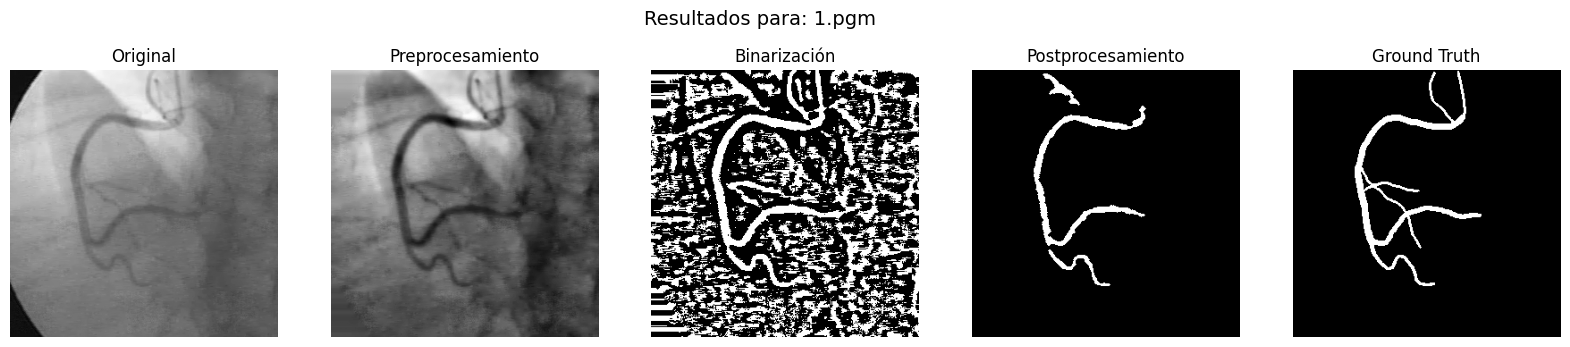

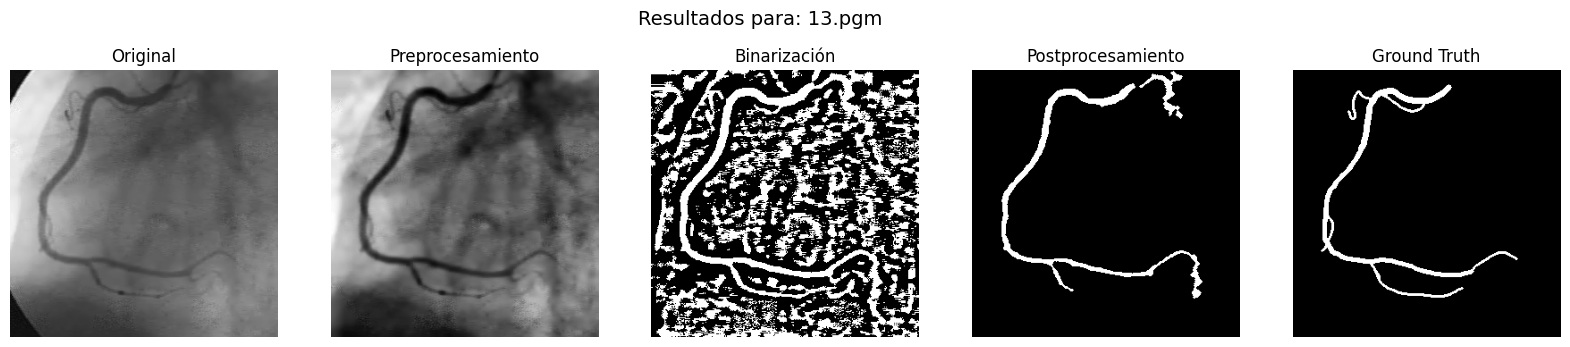

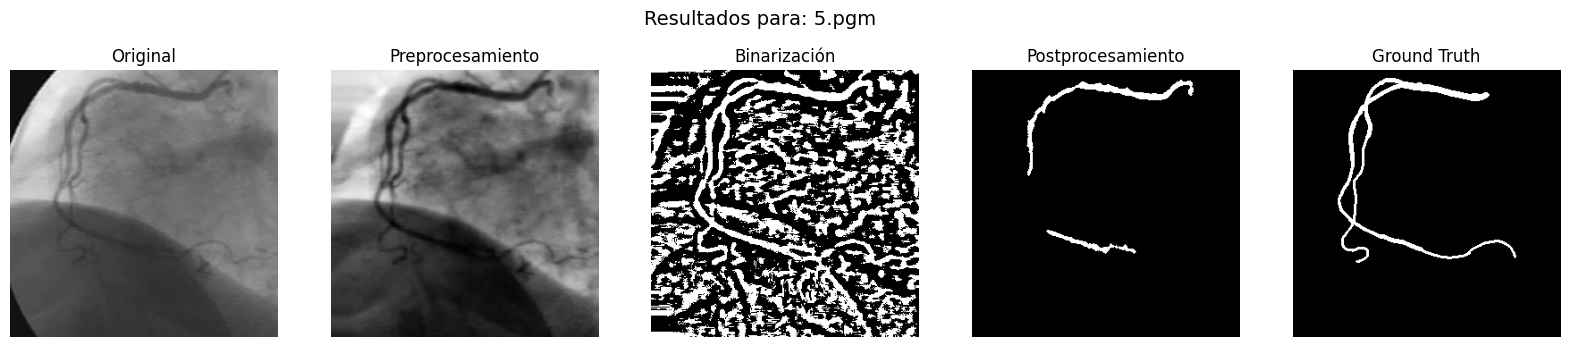

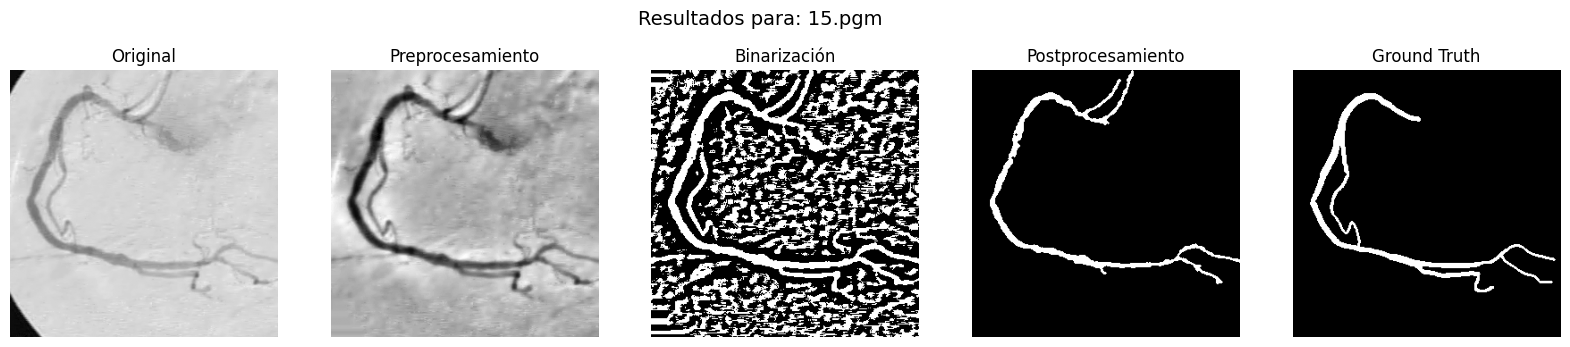

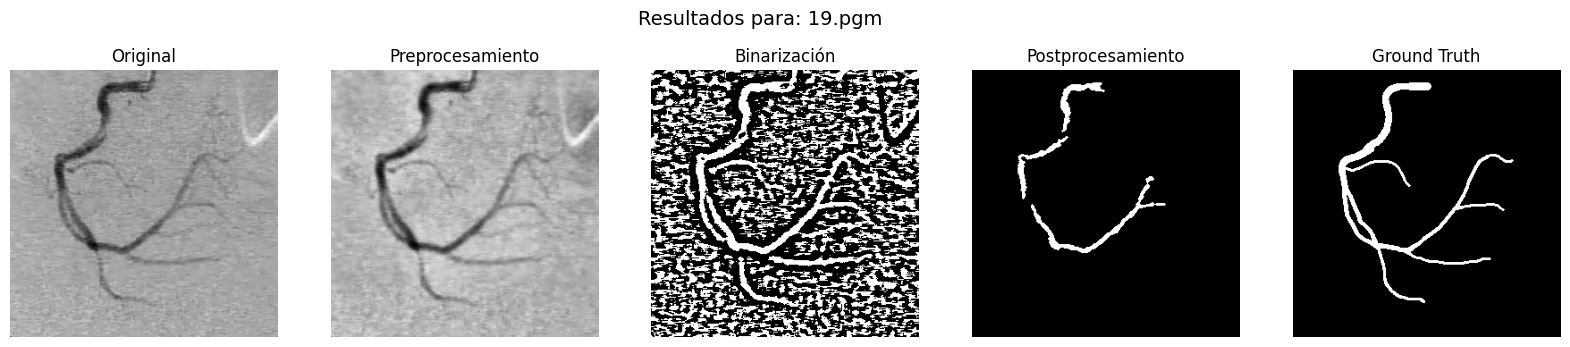

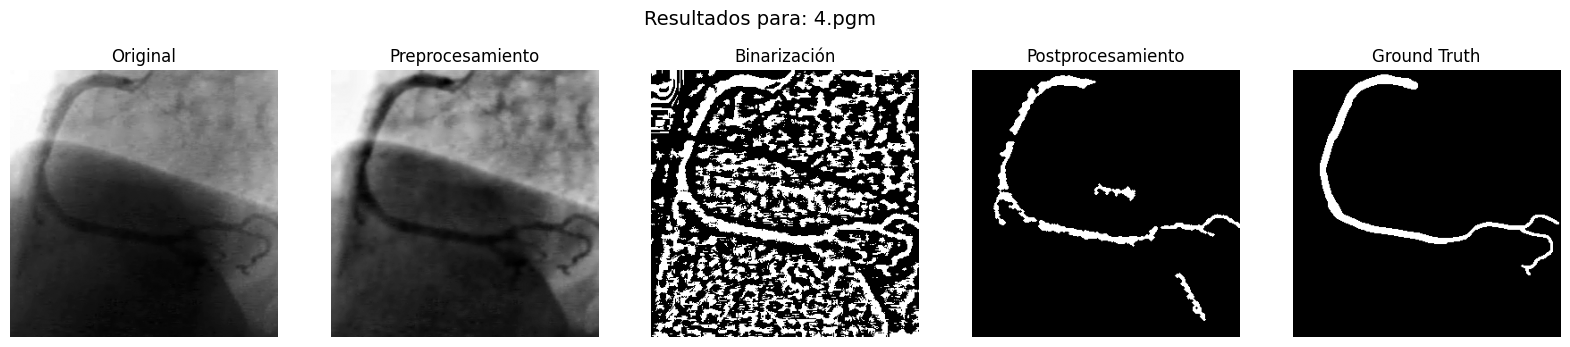

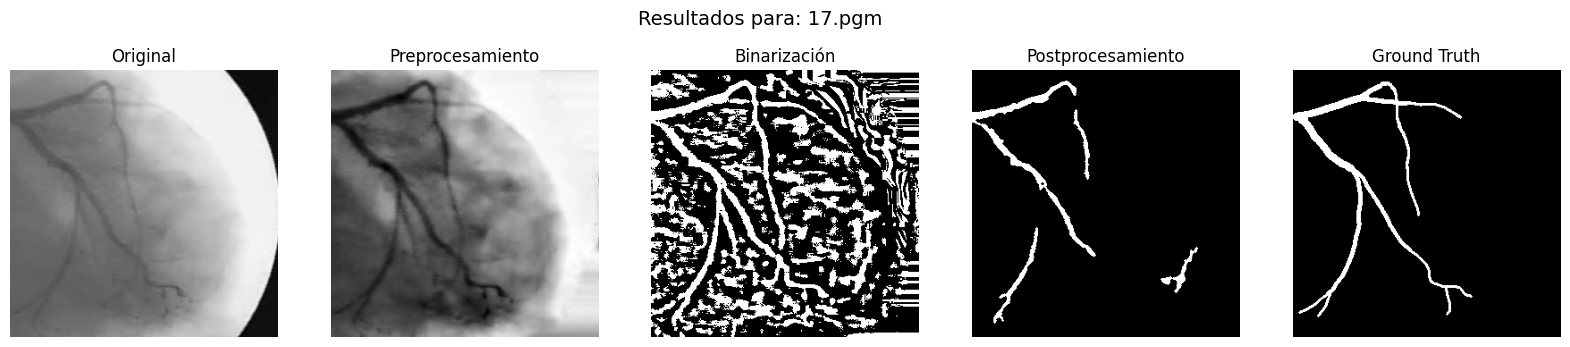

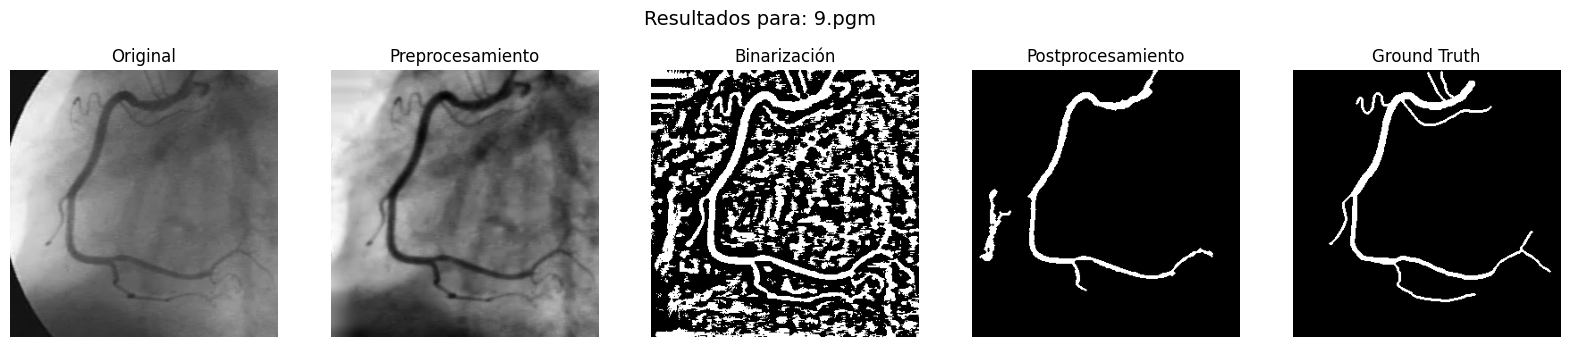

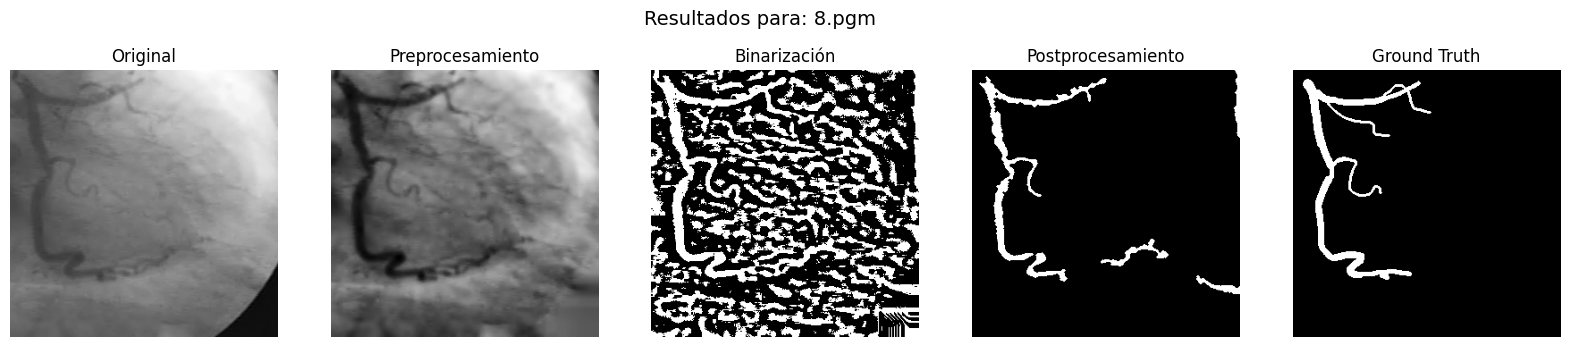

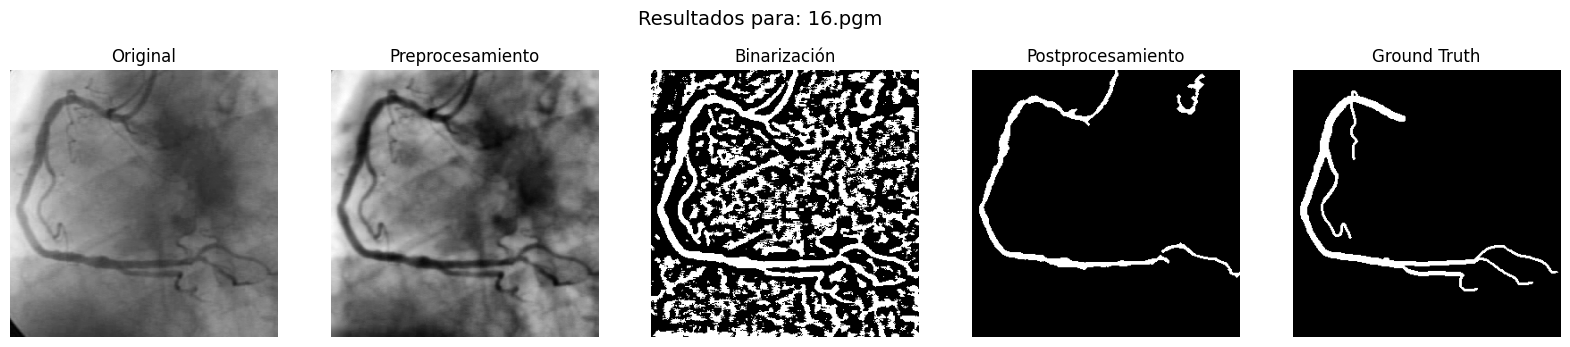

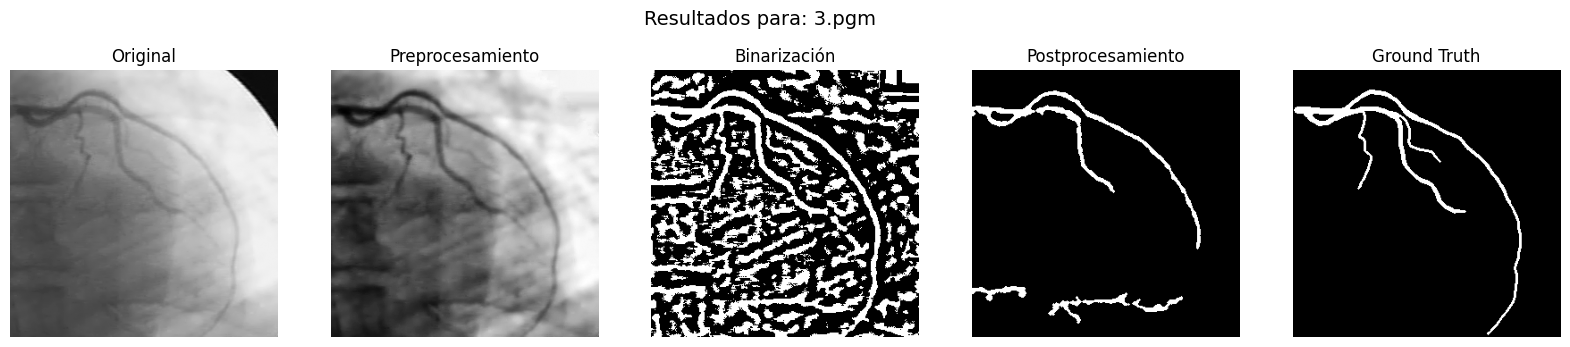

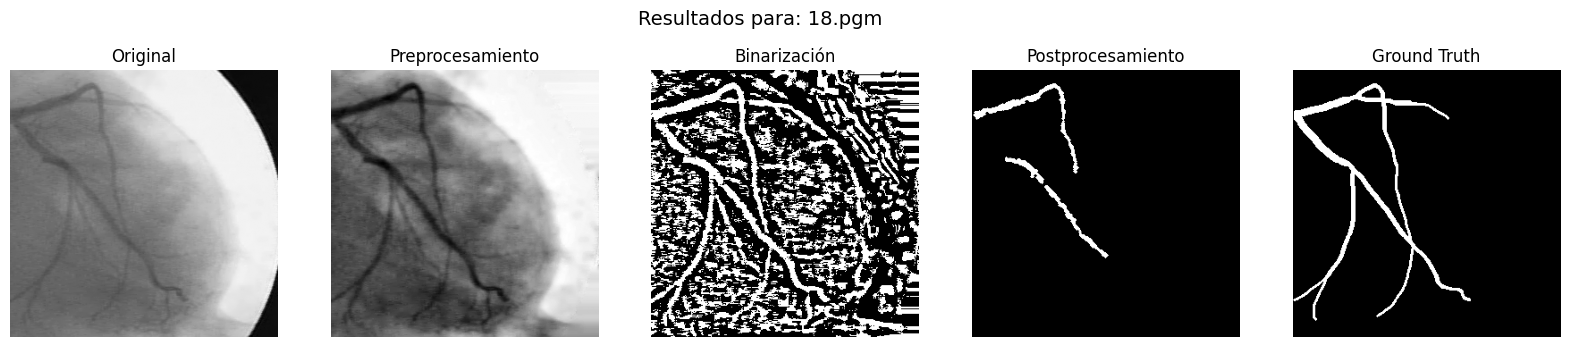

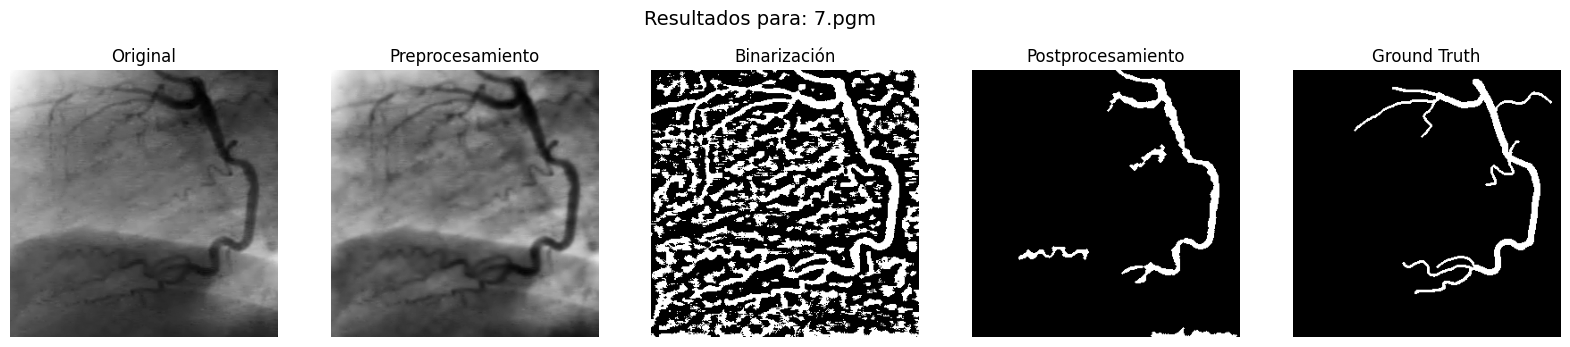

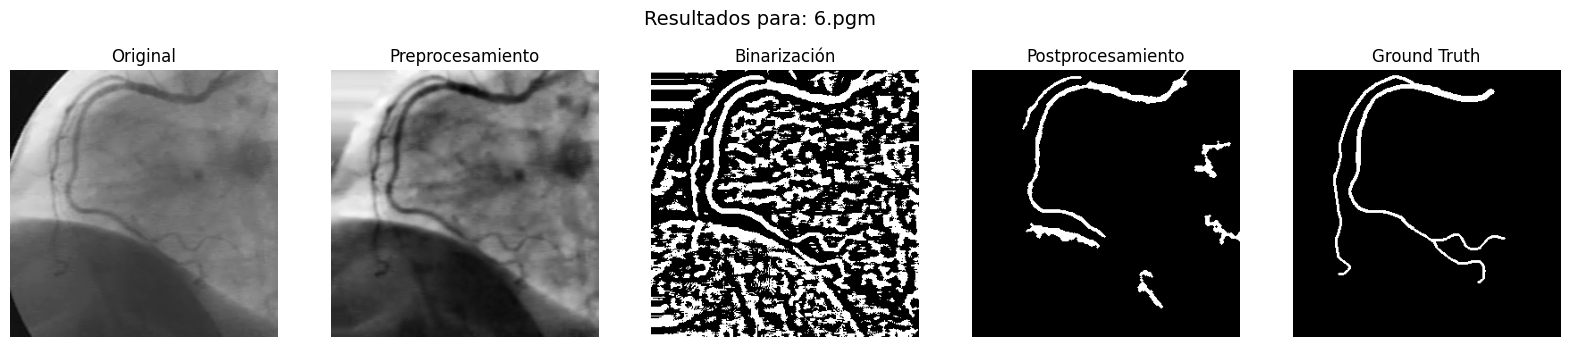

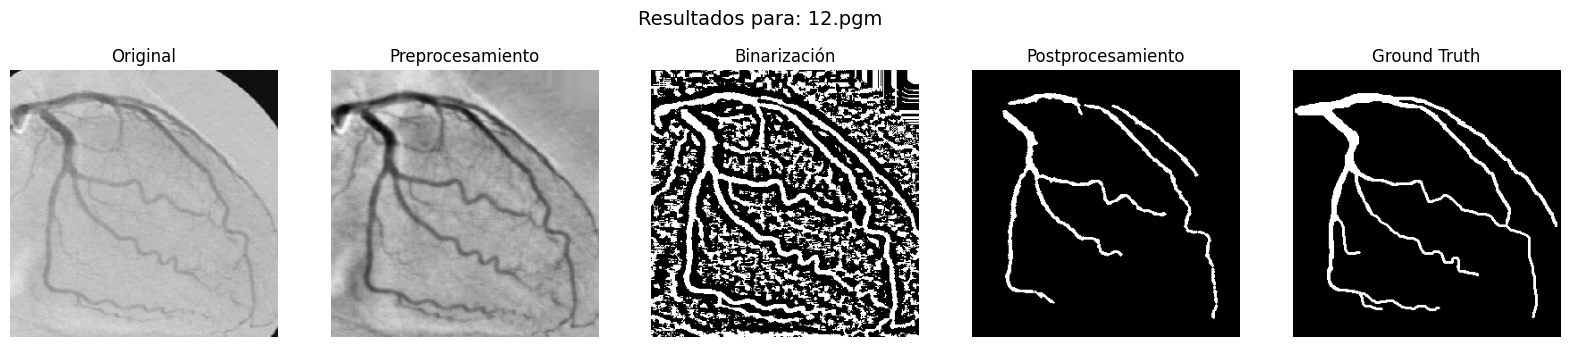

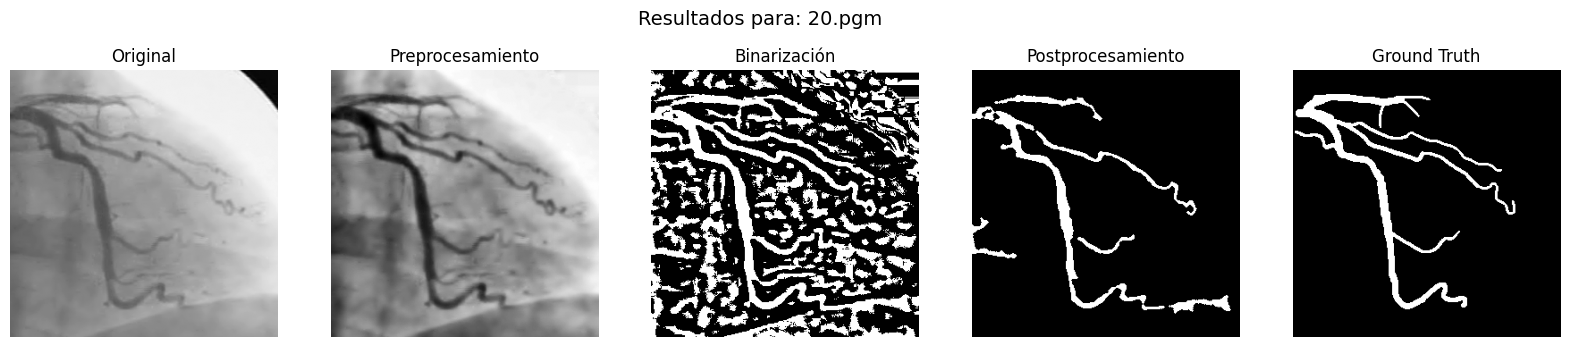

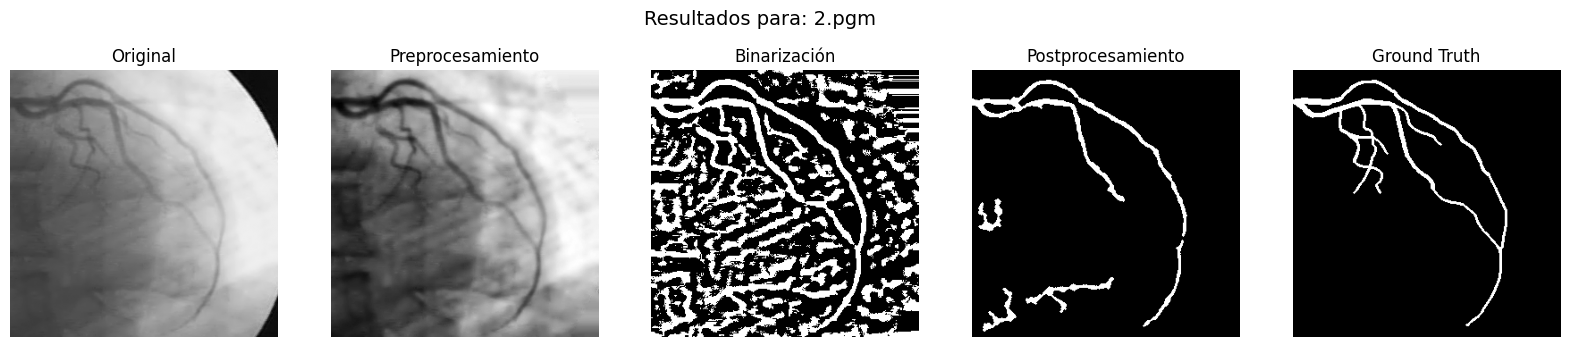

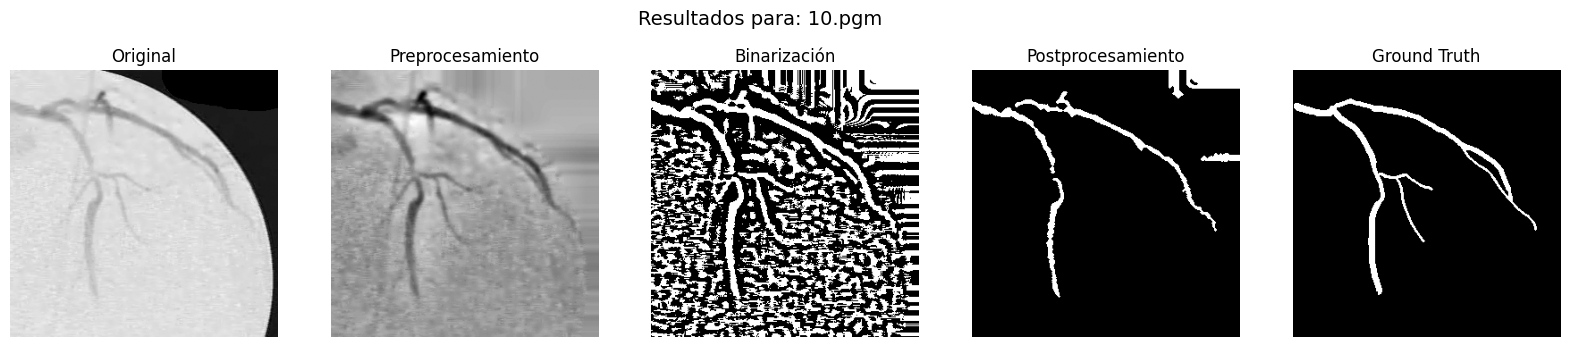

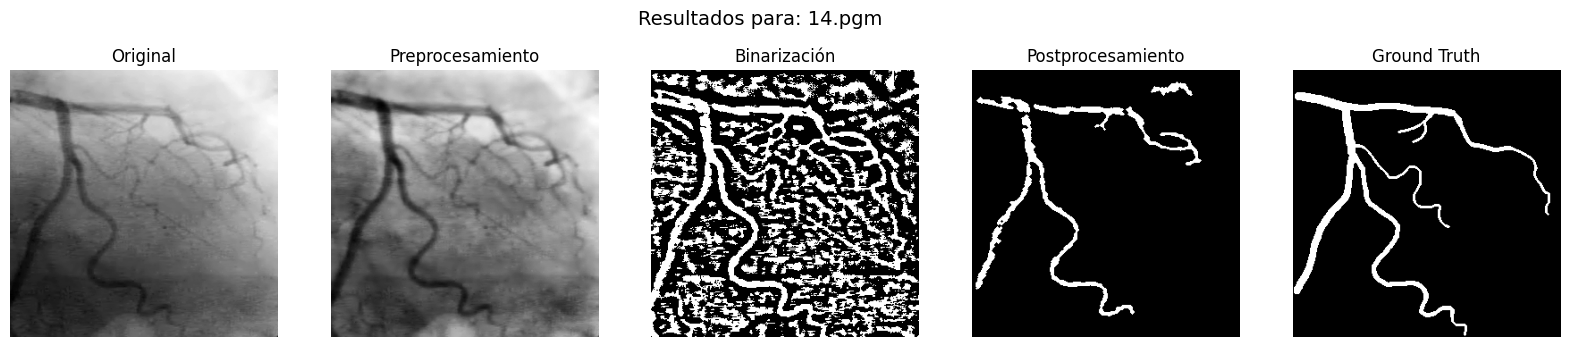

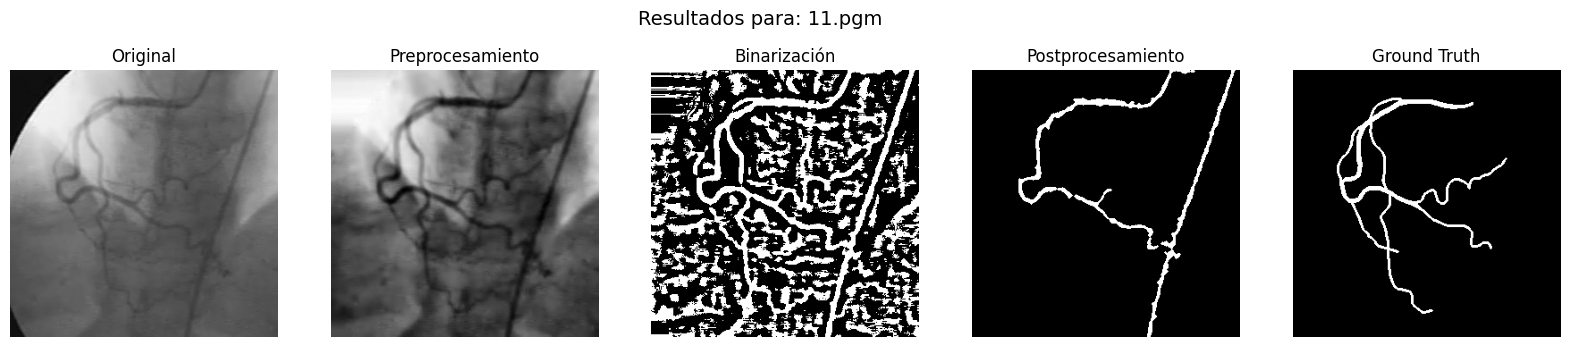

In [8]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate
from concurrent.futures import ThreadPoolExecutor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from skimage.morphology import remove_small_objects


def loadPGM(filename):
    """Carga una imagen en formato PGM."""
    return cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

def processImage(img):
    """Mejora la detección de esquinas negras y aplica inpainting más efectivo."""
    _, mask = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY_INV)
    
    h, w = img.shape
    bordes = [mask[:5, :], mask[h-5:, :], mask[:, :5], mask[:, w-5:]]
    tieneBordeNegro = any(np.sum(b) > 255 * 5 for b in bordes)

    if tieneBordeNegro:
        kernel = np.ones((7, 7), np.uint8)
        maskDilatada = cv2.dilate(mask, kernel, iterations=2)
        imgProcesada = cv2.inpaint(img, maskDilatada, inpaintRadius=5, flags=cv2.INPAINT_NS)
    else:
        imgProcesada = img
    
    return imgProcesada

def adaptiveHistogramEqualization(image):
    """Usa ecualización de histograma adaptativa."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image)

def applyBilateralFilter(image):
    """Aplica filtro bilateral para reducir ruido preservando bordes."""
    return cv2.bilateralFilter(image, d=9, sigmaColor=100, sigmaSpace=100)

def enhanceEdges(image):
    """Resalta bordes usando el filtro Laplaciano."""
    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    laplacian = np.uint8(np.absolute(cv2.Laplacian(blurred, cv2.CV_64F)))
    return cv2.addWeighted(image, 0.7, laplacian, 0.3, 0)

def fuseImages(image1, image2, alpha=0.6):
    """Fusiona dos imágenes con pesos ajustados."""
    return np.clip(alpha * image1.astype(float) + (1 - alpha) * image2.astype(float), 0, 255).astype(np.uint8)

def niblackBinarization(image, windowSize=10, k=-0.2):
    """Binarización de Niblack implementada manualmente sin librerías avanzadas."""
    # Asegurar que el tamaño de ventana sea impar
    if windowSize % 2 == 0:
        windowSize += 1
    
    # Crear una copia de la imagen para el resultado
    height, width = image.shape
    binary = np.zeros_like(image)
    
    # Calcular el offset para el recorrido de la ventana
    offset = windowSize // 2
    
    # Procesar cada píxel de la imagen
    for i in range(height):
        for j in range(width):
            # Definir los límites de la ventana
            y_start = max(0, i - offset)
            y_end = min(height, i + offset + 1)
            x_start = max(0, j - offset)
            x_end = min(width, j + offset + 1)
            
            # Extraer la ventana
            window = image[y_start:y_end, x_start:x_end]
            
            # Calcular la media y desviación estándar de la ventana
            mean = np.mean(window)
            std_dev = np.std(window)
            
            # Calcular el umbral de Niblack
            threshold = mean + k * std_dev
            
            # Aplicar la binarización
            if image[i, j] > threshold:
                binary[i, j] = 255
            else:
                binary[i, j] = 0
    
    # Invertir la imagen binaria (255 - binary)
    return 255 - binary.astype(np.uint8)

def processFile(fileName, directory):
    """Procesa una imagen individual para análisis binario."""
    originalPath = os.path.join(directory, fileName)
    gtPath = os.path.join(directory, fileName.replace(".pgm", "_gt.pgm"))
    
    if not os.path.exists(originalPath) or not os.path.exists(gtPath):
        return None

    image = loadPGM(originalPath)
    groundTruth = loadPGM(gtPath)

    cleanedImage = processImage(image)
    equalizedImage = adaptiveHistogramEqualization(cleanedImage)
    enhancedImage = enhanceEdges(equalizedImage)
    filteredImage = applyBilateralFilter(enhancedImage)
    fusedImage = fuseImages(equalizedImage, filteredImage, alpha=0.4)

    binaryImage = niblackBinarization(fusedImage, windowSize=12, k=-0.2)

    # Aplicar post-procesamiento morfológico
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    postBinary = cv2.morphologyEx(binaryImage, cv2.MORPH_OPEN, kernel)
    postBinary = cv2.erode(postBinary, kernel, iterations=2)
    postBinary = cv2.dilate(postBinary, kernel, iterations=2)
    eroded_image = cv2.erode(postBinary, kernel, iterations=1)

    postBinary = remove_small_objects(eroded_image.astype(bool), min_size=300)
    postBinary = (postBinary * 255).astype(np.uint8)

    # Evaluar precisión comparando con Ground Truth
    accuracy = np.sum(postBinary == groundTruth) / (groundTruth.shape[0] * groundTruth.shape[1])
    
    return {
        'image': image,
        'fileName': fileName,
        'binaryImage': binaryImage,
        'groundTruth': groundTruth,
        'postBinary': postBinary,
        'preBinary': fusedImage,
        'accuracy': accuracy
    }

def computeMetrics(binaryImage, groundTruth):
    """Calcula métricas de precisión y segmentación."""
    binaryImage = (binaryImage > 128).astype(np.uint8)
    groundTruth = (groundTruth > 128).astype(np.uint8)

    accuracy = accuracy_score(groundTruth.flatten(), binaryImage.flatten())
    precision = precision_score(groundTruth.flatten(), binaryImage.flatten(), zero_division=1)
    recall = recall_score(groundTruth.flatten(), binaryImage.flatten(), zero_division=1)
    f1 = f1_score(groundTruth.flatten(), binaryImage.flatten(), zero_division=1)
    
    tn, fp, fn, tp = confusion_matrix(groundTruth.flatten(), binaryImage.flatten()).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return accuracy, recall, specificity, precision, f1



def displayProcessingResults(results):
    """Muestra las imágenes en distintas etapas del procesamiento."""
    
    for result in results:
        fileName = result.get('fileName', 'Unknown')

        # Validar existencia de imágenes antes de graficar
        if any(key not in result for key in ['image','binaryImage', 'groundTruth', 'postBinary', 'preBinary']):
            print(f"⚠️ Error: Faltan imágenes en {fileName}")
            continue
        
        fig, axs = plt.subplots(1, 5, figsize=(20, 4))
        
        axs[0].imshow(result['image'], cmap='gray')
        axs[0].set_title("Original")
        axs[0].axis("off")

        axs[1].imshow(result['preBinary'], cmap='gray')
        axs[1].set_title("Preprocesamiento")
        axs[1].axis("off")

        axs[2].imshow(result['binaryImage'], cmap='gray')
        axs[2].set_title("Binarización")
        axs[2].axis("off")

        axs[3].imshow(result['postBinary'], cmap='gray')
        axs[3].set_title("Postprocesamiento")
        axs[3].axis("off")

        axs[4].imshow(result['groundTruth'], cmap='gray')
        axs[4].set_title("Ground Truth")
        axs[4].axis("off")

        fig.suptitle(f"Resultados para: {fileName}", fontsize=14)
        plt.show()

def evaluateResults(results, output_file="resultadosNiblack.csv"):
    """Evalúa imágenes y genera tabla de métricas."""
    evaluationResults = []

    for result in results:
        fileName = result['fileName']
        binaryImage = result['postBinary']
        groundTruth = result['groundTruth']

        accuracy, recall, specificity, precision, f1 = computeMetrics(binaryImage, groundTruth)

        evaluationResults.append({
            "Imagen": fileName,
            "Accuracy": accuracy,
            "Recall": recall,
            "Specificity": specificity,
            "Precision": precision,
            "F1 Score": f1
        })

    dfResults = pd.DataFrame(evaluationResults)
    avgResults = dfResults.mean(numeric_only=True)
    avgResults["Imagen"] = "Promedio"
    dfResults = pd.concat([dfResults, avgResults.to_frame().T], ignore_index=True)

    dfResults.to_csv(output_file, index=False)

    # Mostrar tabla formateada con tabulate
    print("\nResultados de Evaluación:")
    print(tabulate(dfResults, headers='keys', tablefmt='fancy_grid', showindex=False))

    return dfResults


# Llamar la función después de procesar las imágenes en `main()`
def main():
    """Ejecuta el procesamiento de imágenes y evalúa resultados."""
    directory = "database/database/"
    files = sorted(os.listdir(directory))
    originalNames = [file for file in files if file.endswith(".pgm") and "_gt" not in file]

    results = []
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        futures = [executor.submit(processFile, fileName, directory) for fileName in originalNames]
        for future in futures:
            result = future.result()
            if result:
                results.append(result)

    results.sort(key=lambda x: x['accuracy'], reverse=True)
    
    dfResults = evaluateResults(results, output_file="resultadosNiblack.csv")
    print("\nResumen de Métricas Promedio:")
    print(dfResults[dfResults["Imagen"] == "Promedio"].to_string(index=False))

    # Mostrar la visualización de las imágenes en distintas etapas
    displayProcessingResults(results)

if __name__ == "__main__":
    main()
